In [1]:
import sys, optparse, glob, os, re, string
sys.path.append('../')

from atmopy import *
from atmopy.display import *
import numpy as np
import matplotlib.pyplot as plt

no need to care how I read the data, should replace by your own data here

8518 Ntt


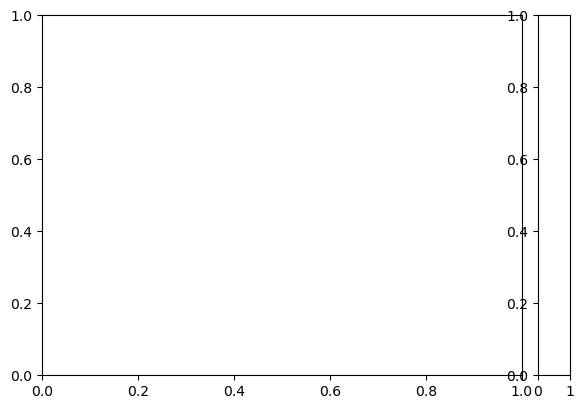

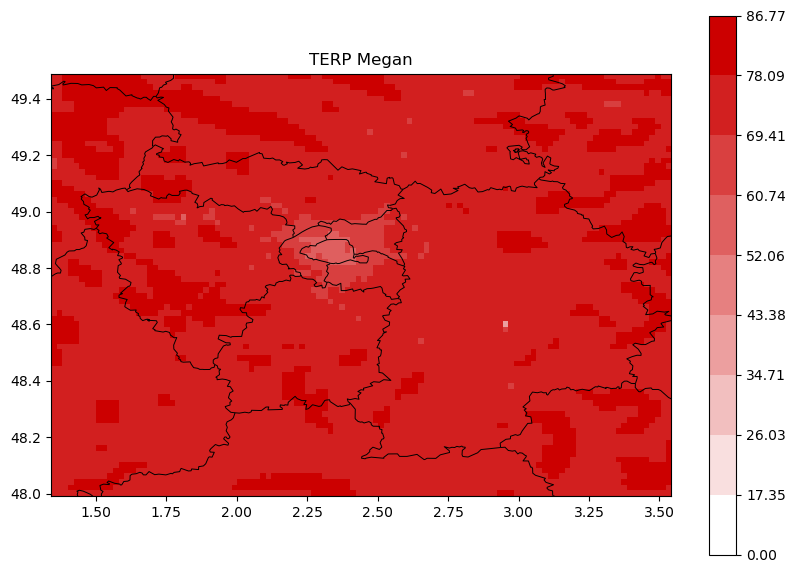

In [3]:
#no need to care how I read the data
disp.x_min = 1.35
disp.y_min = 48.
disp.Delta_x = 0.02
disp.Delta_y = 0.02
disp.Nx = 110
disp.Ny = 75
disp.Nz = 1
#current_file_polair= "/net/libre/mundi/lugonl/these/StreetInGrid/Paris_sim_scenarii/IdF/Polair3d/output/reference/mod_TY_mod_size_TY_RD/results/NO2.bin"

current_file_polair= "/net/libre/mundi/lugonl/these/StreetInGrid/Paris_sim_scenarii/IdF/Polair3d/output/reference/mod_TY_mod_size_TY_RD/results/O3.bin"
#current_file_sing= "/net/libre/bestla/lugonl/StreetInGrid/Paris_sim/Paris/results/final/Polair3dSinG_no-stationary_ts100/NO2.bin"
#current_file= "emission-new/Emissions_tree/Monoterpenes.bin"
Ntt = round((os.path.getsize(current_file_polair))/(4*disp.Ny*disp.Nx))
print(Ntt,'Ntt')
#Ntt = 
Nz =1
d_polair = getd(disp, current_file_polair,Ntt,disp.Nz,disp.Ny,disp.Nx)
#d_sing = getd(disp, current_file_sing,Ntt,disp.Nz,disp.Ny,disp.Nx)
#d = 100*(d_sing - d_polair)/d_polair

d = d_polair

dm = stat.spatial_distribution(d[0:Ntt-1,0],"mean")   
vmax = dm.max() #round(dm.max()+0.5,0)
vmin = dm.min() #round(dm.min()-0.5,0)
vmin = 0.0
v00 = vmin
vvmax = vmax-vmin
v0 = vvmax/10. + vmin
v1 = vvmax* 2. /10. + vmin
v2 = vvmax * 3./10. + vmin
v3 = vvmax * 4./10. + vmin
v4 = vvmax * 5./10. + vmin
v5 = vvmax * 6./10. + vmin
v6 = vvmax * 7./10. + vmin
v7 = vvmax * 8./10. + vmin
v8 = vvmax * 9./10. + vmin
v9 = vvmax  + vmin

rouge = [[0,0,1],[1,0.8,0.8]]
vert = [[0,0,1],[1,0,0]]
bleu = [[0,0,1],[1,0,0]]
color_map = {"blue":  bleu,
             "green": vert,
             "red":   rouge}



Boundaries = {"X" : [v00,v1,v2,v3,v4,v5,v6,v7,v8,v9]}
maps = getm(disp)   
fig = plt.figure(figsize=(10,7))
#cmap = plt.get_cmap('YlOrBr')
cmap = matplotlib.colors.LinearSegmentedColormap('tutu',color_map, len(Boundaries["X"])-1)
norm = matplotlib.colors.BoundaryNorm(Boundaries["X"], cmap.N)
cax = maps.imshow(dm, norm=norm, cmap=cmap)

maps.readshapefile('/cerea_raid/share/data/SIG/GEOFLA_departements/LATLON/LIMITE_DEPARTEMENT', 'bdr',color='black',linewidth=.7,default_encoding='iso-8859-15')
#maps.readshapefile('/cerea_raid/users/legorgec/SIG/GEOFLA_departements/LATLON/LIMITE_DEPARTEMENT', 'bdr',color='black',linewidth=.7)
title("TERP Megan")
#title("TERP Tree")
cbar = fig.colorbar(cax)
#savefig("TERP_megan.png")
plt.show()
plt.close(fig)

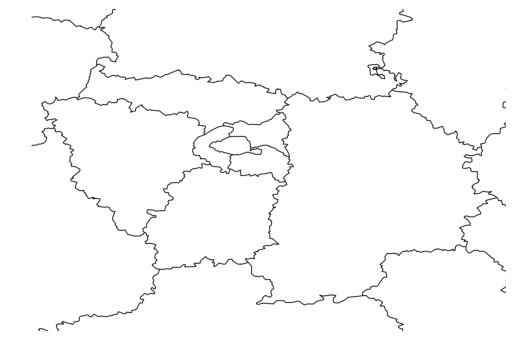

In [4]:
img = np.load("/libre/chengs/data/airparis/map_rgb_adjusted.npy")    
plt.imshow(np.flipud(d[100, 0, :, :]))
plt.imshow(img) 
plt.axis("off")
plt.show()


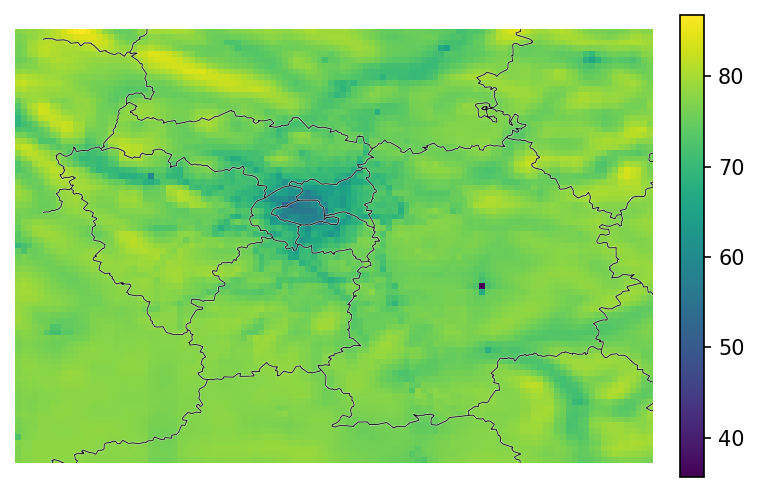

In [6]:
import numpy as np
import matplotlib.pyplot as plt


d_base = d[100, 0, :, :]     # this is your outpt

d_base = dm


img_rgb = img.astype(np.uint8)          # 
mask_lines = (img_rgb < 250).any(axis=2)          
alpha = (mask_lines * 255).astype(np.uint8)       
img_rgba = np.dstack([img_rgb, alpha])            

# --- plot ---
fig, ax = plt.subplots(figsize=(6, 4), dpi=150)


im0 = ax.imshow(
    d_base,
    cmap="viridis",          # choose your colormap
    origin="lower",          #
    interpolation="nearest",
    extent=[0, 110, 0, 75],  # make both layers share the same logical extent
)


ax.imshow(
    img_rgba,
    origin="upper",          
    extent=[0, 110, 0, 75],
    zorder=10                
)

ax.set_xlim(0, 110); ax.set_ylim(0, 75)
ax.axis("off")
plt.colorbar(im0, ax=ax, fraction=0.046, pad=0.04) 
plt.show()


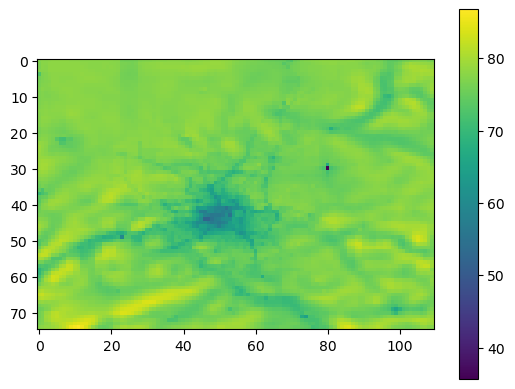

In [ ]:
im = plt.imshow(d_base) #you see image has been flipped!
plt.colorbar(im)